In [1]:
import tensorflow as tf
import xarray as xr
import numpy as np
import pandas as pd
import os

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU devices: []


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_dir = "../data"

netcdf_path = os.path.join(
    base_dir, "west_bengal_climate_final.nc"
)

stats_path = os.path.join(
    base_dir, "normalization_stats.csv"
)

ds = xr.open_dataset(netcdf_path)
stats_df = pd.read_csv(stats_path)

print(stats_df)
print(ds.data_vars)

   variable       mean        std
0  rainfall   4.645871  13.518388
1      tmax  30.690184   4.541145
2      tmin  20.315073   5.800562


In [3]:
variables = ["rainfall", "tmax", "tmin"]

train_mean = stats_df.set_index("variable")["mean"].to_dict()
train_std = stats_df.set_index("variable")["std"].to_dict()

ds_norm = ds.copy()

for var in variables:
    ds_norm[var] = (
        (ds[var] - train_mean[var]) / train_std[var]
    )

print(ds_norm[variables])

<xarray.Dataset> Size: 2MB
Dimensions:    (time: 4018, latitude: 7, longitude: 5)
Coordinates:
  * time       (time) datetime64[ns] 32kB 2015-01-01 2015-01-02 ... 2025-12-31
  * latitude   (latitude) float64 56B 21.5 22.5 23.5 24.5 25.5 26.5 27.5
  * longitude  (longitude) float64 40B 85.5 86.5 87.5 88.5 89.5
Data variables:
    rainfall   (time, latitude, longitude) float64 1MB nan nan ... -0.3437 nan
    tmax       (time, latitude, longitude) float32 563kB nan nan ... -2.588 nan
    tmin       (time, latitude, longitude) float32 563kB nan nan ... -1.919 nan
Attributes:
    title:                      VARUNA Climate Dataset
    description:                Daily IMD rainfall, maximum temperature, and ...
    region:                     West Bengal
    rainfall_source:            IMD 0.25 degree gridded rainfall
    temperature_source:         IMD 1 degree gridded temperature
    processing:                 Rainfall interpolated from 0.25 degree to 1 d...
    geographic_mask:           

In [4]:
# Keep the original chronological order
dates = pd.to_datetime(ds_norm.time.values)

# Shape: (time, latitude, longitude, channels)
data = np.stack(
    [ds_norm[var].values for var in variables],
    axis=-1
).astype(np.float32)

# Shape: (latitude, longitude)
mask = ds_norm["west_bengal_mask"].values.astype(bool)

print("Data shape:", data.shape)
print("Mask shape:", mask.shape)
print("Valid geographic cells:", mask.sum())
print("First date:", dates[0])
print("Last date:", dates[-1])

Data shape: (4018, 7, 5, 3)
Mask shape: (7, 5)
Valid geographic cells: 14
First date: 2015-01-01 00:00:00
Last date: 2025-12-31 00:00:00


In [6]:
valid_data = data[:, mask, :]

print("Valid-cell data shape:", valid_data.shape)
print("NaNs in valid cells:", np.isnan(valid_data).sum())
print("Infinite values:", np.isinf(valid_data).sum())

assert not np.isnan(valid_data).any(), (
    "Missing values found inside valid cells."
)

assert not np.isinf(valid_data).any(), (
    "Infinite values found in the dataset."
)

print("PASS: Valid cells contain no missing or infinite values.")

Valid-cell data shape: (4018, 14, 3)
NaNs in valid cells: 0
Infinite values: 0
PASS: Valid cells contain no missing or infinite values.


In [7]:
# Split boundaries are exclusive end indices
train_end = 2922
val_end = 2922 + 731
test_end = 4018

split_ranges = {
    "train": (7, train_end),
    "validation": (train_end, val_end),
    "test": (val_end, test_end)
}

for name, (start, end) in split_ranges.items():
    print(
        name,
        "| target period:",
        dates[start],
        "to",
        dates[end - 1]
    )

train | target period: 2015-01-08 00:00:00 to 2022-12-31 00:00:00
validation | target period: 2023-01-01 00:00:00 to 2024-12-31 00:00:00
test | target period: 2025-01-01 00:00:00 to 2025-12-31 00:00:00


In [8]:
def create_sequences(data, dates, mask, horizon, start_idx, end_idx):
    """
    data:      (time, latitude, longitude, channels)
    horizon:   number of future days to predict
    start_idx: first allowed target index
    end_idx:   exclusive end of allowed target period
    """

    X_conv_list = []
    y_list = []
    target_dates = []

    # t is the first day being predicted
    for t in range(start_idx, end_idx - horizon + 1):

        # Seven observations immediately before target day t
        x = data[t-7:t]

        # Future target days: t through t+horizon-1
        y = data[t:t+horizon]

        # Replace masked-out spatial cells with zero.
        # The geographic mask will exclude these cells from the loss.
        x = np.where(np.isfinite(x), x, 0.0)
        y = np.where(np.isfinite(y), y, 0.0)

        X_conv_list.append(x)
        y_list.append(y)
        target_dates.append(dates[t])

    X_conv = np.asarray(X_conv_list, dtype=np.float32)
    y = np.asarray(y_list, dtype=np.float32)

    # Normal LSTM: flatten each 7×5×3 daily grid into 105 features.
    X_lstm = X_conv.reshape(X_conv.shape[0], 7, -1)

    return X_lstm, X_conv, y, np.asarray(target_dates)

In [9]:
processed_dir = os.path.join(base_dir, "sequences")
os.makedirs(processed_dir, exist_ok=True)

horizons = [1, 3, 7]

sequence_data = {}

for horizon in horizons:
    sequence_data[horizon] = {}

    print(f"\n{'='*45}")
    print(f"FORECAST HORIZON: {horizon} day(s)")
    print(f"{'='*45}")

    for split_name, (start_idx, end_idx) in split_ranges.items():

        X_lstm, X_conv, y, target_dates = create_sequences(
            data=data,
            dates=dates,
            mask=mask,
            horizon=horizon,
            start_idx=start_idx,
            end_idx=end_idx
        )

        sequence_data[horizon][split_name] = {
            "X_lstm": X_lstm,
            "X_conv": X_conv,
            "y": y,
            "target_dates": target_dates
        }

        print(
            f"{split_name:10s} | "
            f"LSTM input: {X_lstm.shape} | "
            f"ConvLSTM input: {X_conv.shape} | "
            f"Target: {y.shape}"
        )


FORECAST HORIZON: 1 day(s)
train      | LSTM input: (2915, 7, 105) | ConvLSTM input: (2915, 7, 7, 5, 3) | Target: (2915, 1, 7, 5, 3)
validation | LSTM input: (731, 7, 105) | ConvLSTM input: (731, 7, 7, 5, 3) | Target: (731, 1, 7, 5, 3)
test       | LSTM input: (365, 7, 105) | ConvLSTM input: (365, 7, 7, 5, 3) | Target: (365, 1, 7, 5, 3)

FORECAST HORIZON: 3 day(s)
train      | LSTM input: (2913, 7, 105) | ConvLSTM input: (2913, 7, 7, 5, 3) | Target: (2913, 3, 7, 5, 3)
validation | LSTM input: (729, 7, 105) | ConvLSTM input: (729, 7, 7, 5, 3) | Target: (729, 3, 7, 5, 3)
test       | LSTM input: (363, 7, 105) | ConvLSTM input: (363, 7, 7, 5, 3) | Target: (363, 3, 7, 5, 3)

FORECAST HORIZON: 7 day(s)
train      | LSTM input: (2909, 7, 105) | ConvLSTM input: (2909, 7, 7, 5, 3) | Target: (2909, 7, 7, 5, 3)
validation | LSTM input: (725, 7, 105) | ConvLSTM input: (725, 7, 7, 5, 3) | Target: (725, 7, 7, 5, 3)
test       | LSTM input: (359, 7, 105) | ConvLSTM input: (359, 7, 7, 5, 3) | Target

In [10]:
for horizon in horizons:
    print(f"\nHorizon: {horizon} day(s)")

    for split_name in ["train", "validation", "test"]:
        item = sequence_data[horizon][split_name]

        print(
            split_name,
            "| samples:", len(item["X_conv"]),
            "| first target:", item["target_dates"][0],
            "| last target:", item["target_dates"][-1]
        )

        assert item["X_lstm"].shape[1:] == (7, 105)
        assert item["X_conv"].shape[1:] == (7, 7, 5, 3)
        assert item["y"].shape[1:] == (horizon, 7, 5, 3)

print("\nPASS: All sequence shapes are correct.")


Horizon: 1 day(s)
train | samples: 2915 | first target: 2015-01-08 00:00:00 | last target: 2022-12-31 00:00:00
validation | samples: 731 | first target: 2023-01-01 00:00:00 | last target: 2024-12-31 00:00:00
test | samples: 365 | first target: 2025-01-01 00:00:00 | last target: 2025-12-31 00:00:00

Horizon: 3 day(s)
train | samples: 2913 | first target: 2015-01-08 00:00:00 | last target: 2022-12-29 00:00:00
validation | samples: 729 | first target: 2023-01-01 00:00:00 | last target: 2024-12-29 00:00:00
test | samples: 363 | first target: 2025-01-01 00:00:00 | last target: 2025-12-29 00:00:00

Horizon: 7 day(s)
train | samples: 2909 | first target: 2015-01-08 00:00:00 | last target: 2022-12-25 00:00:00
validation | samples: 725 | first target: 2023-01-01 00:00:00 | last target: 2024-12-25 00:00:00
test | samples: 359 | first target: 2025-01-01 00:00:00 | last target: 2025-12-25 00:00:00

PASS: All sequence shapes are correct.


In [11]:
print("Number of valid cells:", int(mask.sum()))
print("Number of excluded cells:", int(mask.size - mask.sum()))

for horizon in horizons:
    y = sequence_data[horizon]["train"]["y"]

    # Check that placeholder values outside the geographic mask are zero.
    excluded_values = y[:, :, ~mask, :]

    print(
        f"{horizon}-day forecast | "
        f"maximum absolute excluded target value:",
        np.max(np.abs(excluded_values))
    )

Number of valid cells: 14
Number of excluded cells: 21
1-day forecast | maximum absolute excluded target value: 0.0
3-day forecast | maximum absolute excluded target value: 0.0
7-day forecast | maximum absolute excluded target value: 0.0


In [12]:
for horizon in horizons:
    for split_name in ["train", "validation", "test"]:

        item = sequence_data[horizon][split_name]

        output_path = os.path.join(
            processed_dir,
            f"{split_name}_{horizon}day.npz"
        )

        np.savez_compressed(
            output_path,
            X_lstm=item["X_lstm"],
            X_conv=item["X_conv"],
            y=item["y"],
            target_dates=item["target_dates"],
            mask=mask,
            variables=np.array(variables)
        )

        print("Saved:", output_path)

Saved: ../data\sequences\train_1day.npz
Saved: ../data\sequences\validation_1day.npz
Saved: ../data\sequences\test_1day.npz
Saved: ../data\sequences\train_3day.npz
Saved: ../data\sequences\validation_3day.npz
Saved: ../data\sequences\test_3day.npz
Saved: ../data\sequences\train_7day.npz
Saved: ../data\sequences\validation_7day.npz
Saved: ../data\sequences\test_7day.npz


In [13]:
check_path = os.path.join(processed_dir, "train_1day.npz")

with np.load(check_path) as saved:
    for key in saved.files:
        print(key, saved[key].shape)

X_lstm (2915, 7, 105)
X_conv (2915, 7, 7, 5, 3)
y (2915, 1, 7, 5, 3)


ValueError: Object arrays cannot be loaded when allow_pickle=False

In [14]:

import numpy as np
import os

check_path = os.path.join(processed_dir, "train_1day.npz")

with np.load(check_path, allow_pickle=False) as saved:
    print("Arrays stored in the file:", saved.files)

    for key in saved.files:
        try:
            arr = saved[key]
            print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")
        except ValueError as e:
            print(f"{key}: Could not load normally")
            print("Reason:", e)


Arrays stored in the file: ['X_lstm', 'X_conv', 'y', 'target_dates', 'mask', 'variables']
X_lstm: shape=(2915, 7, 105), dtype=float32
X_conv: shape=(2915, 7, 7, 5, 3), dtype=float32
y: shape=(2915, 1, 7, 5, 3), dtype=float32
target_dates: Could not load normally
Reason: Object arrays cannot be loaded when allow_pickle=False
mask: shape=(7, 5), dtype=bool
variables: shape=(3,), dtype=<U8


In [15]:

with np.load(check_path, allow_pickle=True) as saved:
    dates = saved["target_dates"]

    print("Shape:", dates.shape)
    print("Data type:", dates.dtype)
    print("First 5 dates:", dates[:5])
    print("Last 5 dates:", dates[-5:])


Shape: (2915,)
Data type: object
First 5 dates: [Timestamp('2015-01-08 00:00:00') Timestamp('2015-01-09 00:00:00')
 Timestamp('2015-01-10 00:00:00') Timestamp('2015-01-11 00:00:00')
 Timestamp('2015-01-12 00:00:00')]
Last 5 dates: [Timestamp('2022-12-27 00:00:00') Timestamp('2022-12-28 00:00:00')
 Timestamp('2022-12-29 00:00:00') Timestamp('2022-12-30 00:00:00')
 Timestamp('2022-12-31 00:00:00')]


In [16]:

target_dates = np.asarray(target_dates, dtype="datetime64[ns]")


In [17]:

np.savez_compressed(
    output_path,
    X_lstm=X_lstm.astype(np.float32),
    X_conv=X_conv.astype(np.float32),
    y=y.astype(np.float32),
    target_dates=np.asarray(target_dates, dtype="datetime64[ns]"),
    mask=mask.astype(bool),
    variables=np.asarray(variables, dtype=str)
)


In [18]:

with np.load(check_path, allow_pickle=False) as saved:
    for key in saved.files:
        arr = saved[key]
        print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")


X_lstm: shape=(2915, 7, 105), dtype=float32
X_conv: shape=(2915, 7, 7, 5, 3), dtype=float32
y: shape=(2915, 1, 7, 5, 3), dtype=float32


ValueError: Object arrays cannot be loaded when allow_pickle=False

In [19]:

import numpy as np
import os

check_path = os.path.join(processed_dir, "train_1day.npz")
fixed_path = os.path.join(processed_dir, "train_1day_fixed.npz")

# Only do this for your own trusted, locally generated file.
with np.load(check_path, allow_pickle=True) as saved:
    arrays = {key: saved[key] for key in saved.files}

# Convert dates from object dtype to native NumPy datetime
arrays["target_dates"] = np.asarray(
    arrays["target_dates"], dtype="datetime64[ns]"
)

# Save a corrected copy
np.savez_compressed(fixed_path, **arrays)

print("Corrected file saved:", fixed_path)
print("Target dates dtype:", arrays["target_dates"].dtype)
print("First 5 dates:", arrays["target_dates"][:5])


Corrected file saved: ../data\sequences\train_1day_fixed.npz
Target dates dtype: datetime64[ns]
First 5 dates: ['2015-01-08T00:00:00.000000000' '2015-01-09T00:00:00.000000000'
 '2015-01-10T00:00:00.000000000' '2015-01-11T00:00:00.000000000'
 '2015-01-12T00:00:00.000000000']


In [20]:

with np.load(fixed_path, allow_pickle=False) as saved:
    for key in saved.files:
        arr = saved[key]
        print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")


X_lstm: shape=(2915, 7, 105), dtype=float32
X_conv: shape=(2915, 7, 7, 5, 3), dtype=float32
y: shape=(2915, 1, 7, 5, 3), dtype=float32
target_dates: shape=(2915,), dtype=datetime64[ns]
mask: shape=(7, 5), dtype=bool
variables: shape=(3,), dtype=<U8


In [21]:

with np.load(fixed_path, allow_pickle=False) as saved:
    dates = saved["target_dates"]

    print("First target date:", dates[0])
    print("Last target date:", dates[-1])
    print("Number of samples:", len(dates))
    print("Dates are chronological:", np.all(dates[1:] > dates[:-1]))


First target date: 2015-01-08T00:00:00.000000000
Last target date: 2022-12-31T00:00:00.000000000
Number of samples: 2915
Dates are chronological: True


In [22]:

import os
import numpy as np

sequence_dir = os.path.join(
    "../data", "sequences"
)

for filename in [
    "train_1day_fixed.npz",
    "validation_1day.npz",
    "test_1day.npz"
]:
    path = os.path.join(sequence_dir, filename)
    print(filename, "exists:", os.path.exists(path))


train_1day_fixed.npz exists: True
validation_1day.npz exists: True
test_1day.npz exists: True


In [23]:

train_path = os.path.join(processed_dir, "train_1day_fixed.npz")
val_path = os.path.join(processed_dir, "validation_1day.npz")
test_path = os.path.join(processed_dir, "test_1day.npz")

def load_sequences(path):
    with np.load(path, allow_pickle=False) as data:
        return {key: data[key] for key in data.files}

train_data = load_sequences(train_path)
val_data = load_sequences(val_path)
test_data = load_sequences(test_path)

X_train = train_data["X_lstm"]
y_train = train_data["y"]

X_val = val_data["X_lstm"]
y_val = val_data["y"]

X_test = test_data["X_lstm"]
y_test = test_data["y"]

mask = train_data["mask"]

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)
print("Selected grid cells:", mask.sum())


ValueError: Object arrays cannot be loaded when allow_pickle=False

In [24]:

import os
import numpy as np

for filename in ["validation_1day.npz", "test_1day.npz"]:
    path = os.path.join(processed_dir, filename)

    print(f"\n--- {filename} ---")

    with np.load(path, allow_pickle=False) as saved:
        for key in saved.files:
            try:
                arr = saved[key]
                print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")
            except ValueError:
                print(f"{key}: OBJECT ARRAY — needs correction")



--- validation_1day.npz ---
X_lstm: shape=(731, 7, 105), dtype=float32
X_conv: shape=(731, 7, 7, 5, 3), dtype=float32
y: shape=(731, 1, 7, 5, 3), dtype=float32
target_dates: OBJECT ARRAY — needs correction
mask: shape=(7, 5), dtype=bool
variables: shape=(3,), dtype=<U8

--- test_1day.npz ---
X_lstm: shape=(365, 7, 105), dtype=float32
X_conv: shape=(365, 7, 7, 5, 3), dtype=float32
y: shape=(365, 1, 7, 5, 3), dtype=float32
target_dates: OBJECT ARRAY — needs correction
mask: shape=(7, 5), dtype=bool
variables: shape=(3,), dtype=<U8


In [25]:

def fix_date_array(source_path, output_path):
    with np.load(source_path, allow_pickle=True) as saved:
        arrays = {key: saved[key] for key in saved.files}

    if "target_dates" in arrays:
        arrays["target_dates"] = np.asarray(
            arrays["target_dates"],
            dtype="datetime64[ns]"
        )

    np.savez_compressed(output_path, **arrays)
    print("Corrected:", output_path)


val_path = os.path.join(processed_dir, "validation_1day.npz")
test_path = os.path.join(processed_dir, "test_1day.npz")

val_fixed_path = os.path.join(
    processed_dir, "validation_1day_fixed.npz"
)
test_fixed_path = os.path.join(
    processed_dir, "test_1day_fixed.npz"
)

fix_date_array(val_path, val_fixed_path)
fix_date_array(test_path, test_fixed_path)


Corrected: ../data\sequences\validation_1day_fixed.npz
Corrected: ../data\sequences\test_1day_fixed.npz


In [26]:

train_path = os.path.join(processed_dir, "train_1day_fixed.npz")

train_data = load_sequences(train_path)
val_data = load_sequences(val_fixed_path)
test_data = load_sequences(test_fixed_path)

X_train, y_train = train_data["X_lstm"], train_data["y"]
X_val, y_val = val_data["X_lstm"], val_data["y"]
X_test, y_test = test_data["X_lstm"], test_data["y"]

mask = train_data["mask"]

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)
print("Selected grid cells:", mask.sum())


Training: (2915, 7, 105) (2915, 1, 7, 5, 3)
Validation: (731, 7, 105) (731, 1, 7, 5, 3)
Testing: (365, 7, 105) (365, 1, 7, 5, 3)
Selected grid cells: 14


In [27]:

# Verify that all three splits use the same spatial mask
print("Training mask cells:", train_data["mask"].sum())
print("Validation mask cells:", val_data["mask"].sum())
print("Test mask cells:", test_data["mask"].sum())

assert np.array_equal(train_data["mask"], val_data["mask"])
assert np.array_equal(train_data["mask"], test_data["mask"])

print("All splits use the same spatial mask.")


Training mask cells: 14
Validation mask cells: 14
Test mask cells: 14
All splits use the same spatial mask.


In [28]:

# Flatten the 7 x 5 spatial mask into 35 indicators
mask_features = mask.astype(np.float32).reshape(1, 1, 35)

def add_mask_features(X):
    # X shape: (samples, 7 days, 105 features)
    mask_repeated = np.broadcast_to(
        mask_features,
        (X.shape[0], X.shape[1], 35)
    )
    return np.concatenate([X, mask_repeated], axis=-1).astype(
        np.float32
    )

X_train_lstm = add_mask_features(X_train)
X_val_lstm = add_mask_features(X_val)
X_test_lstm = add_mask_features(X_test)

print("Training input:", X_train_lstm.shape)
print("Validation input:", X_val_lstm.shape)
print("Test input:", X_test_lstm.shape)


Training input: (2915, 7, 140)
Validation input: (731, 7, 140)
Test input: (365, 7, 140)


In [29]:

import tensorflow as tf
from tensorflow.keras import layers, Model

tf.keras.utils.set_random_seed(42)

inputs = layers.Input(shape=(7, 140), name="climate_history")

x = layers.LSTM(64)(inputs)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(7 * 5 * 3)(x)

outputs = layers.Reshape((1, 7, 5, 3))(x)

lstm_model = Model(inputs, outputs, name="VARUNA_LSTM")
lstm_model.summary()


Model: "VARUNA_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ climate_history (InputLayer)    │ (None, 7, 140)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        52,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 105)            │        13,545 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 7, 5, 3)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,345 (290.41 KB)

 Trainable params: 74,345 (290.41 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:

print("Mask shape:", mask.shape)
print("Selected cells:", int(mask.sum()))
print("Target shape:", y_train.shape)

# Check whether target values are finite
print("All target values finite:", np.isfinite(y_train).all())

# Check that the mask is identical across splits
assert np.array_equal(train_data["mask"], val_data["mask"])
assert np.array_equal(train_data["mask"], test_data["mask"])

# Check target values in excluded cells
excluded = ~mask
excluded_values = y_train[:, :, excluded, :]

print("Excluded-cell target shape:", excluded_values.shape)
print("Excluded-cell values are all zero:",
      np.allclose(excluded_values, 0.0))


Mask shape: (7, 5)
Selected cells: 14
Target shape: (2915, 1, 7, 5, 3)
All target values finite: True
Excluded-cell target shape: (2915, 1, 21, 3)
Excluded-cell values are all zero: True


In [31]:

mask_tf = tf.constant(
    mask.astype(np.float32)[None, None, :, :, None]
)

def masked_mse(y_true, y_pred):
    squared_error = tf.square(y_true - y_pred) * mask_tf

    denominator = (
        tf.reduce_sum(mask_tf)
        * tf.cast(
            tf.shape(y_true)[0] * tf.shape(y_true)[1] * 3,
            tf.float32
        )
    )

    return tf.reduce_sum(squared_error) / denominator

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=masked_mse
)

print("LSTM compiled successfully.")


LSTM compiled successfully.


In [32]:

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm,
    y_train,
    validation_data=(X_val_lstm, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    shuffle=True,
    verbose=1
)


Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.4630 - val_loss: 0.3155
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3266 - val_loss: 0.2805
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3031 - val_loss: 0.2646
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2908 - val_loss: 0.2561
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2819 - val_loss: 0.2513
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2750 - val_loss: 0.2456
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2692 - val_loss: 0.2441
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2639 - val_loss: 0.2409
Epoch 9/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2609 - val_loss: 0.2399
Epoch 10/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2572 - val_loss: 0.2398
Epoch 11/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2519 - val_loss: 0.2404
Epoch 12/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2493 - val_l

In [33]:

best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
best_val_loss = float(np.min(history.history["val_loss"]))

print("Best epoch:", best_epoch)
print("Best validation loss:", round(best_val_loss, 4))
print("Epochs completed:", len(history.history["loss"]))


Best epoch: 12
Best validation loss: 0.2392
Epochs completed: 20


In [34]:

model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "varuna_lstm_1day.keras")
history_path = os.path.join(model_dir, "varuna_lstm_1day_history.npz")

lstm_model.save(model_path)

np.savez_compressed(
    history_path,
    loss=np.asarray(history.history["loss"]),
    val_loss=np.asarray(history.history["val_loss"])
)

print("Model saved:", model_path)
print("History saved:", history_path)


Model saved: ../models\varuna_lstm_1day.keras
History saved: ../models\varuna_lstm_1day_history.npz


In [35]:

import os
import numpy as np
import tensorflow as tf

model_path = "../models/varuna_lstm_1day.keras"

# Load the trained model without recompiling its custom loss
loaded_lstm = tf.keras.models.load_model(
    model_path,
    compile=False
)

# Predict the 2025 test period
y_pred_norm = loaded_lstm.predict(
    X_test_lstm,
    batch_size=32,
    verbose=1
)

print("Prediction shape:", y_pred_norm.shape)
print("Actual target shape:", y_test.shape)
print("Predictions are finite:", np.isfinite(y_pred_norm).all())


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
Prediction shape: (365, 1, 7, 5, 3)
Actual target shape: (365, 1, 7, 5, 3)
Predictions are finite: True


In [36]:

# Variable order: rainfall, tmax, tmin
means = np.array([4.645871, 30.690012, 20.315042],
                 dtype=np.float32)

stds = np.array([13.518388, 4.541152, 5.800548],
                dtype=np.float32)

# Reverse z-score normalization
y_pred = y_pred_norm * stds.reshape(1, 1, 1, 1, 3) \
          + means.reshape(1, 1, 1, 1, 3)

y_actual = y_test * stds.reshape(1, 1, 1, 1, 3) \
            + means.reshape(1, 1, 1, 1, 3)

print("Predictions converted to original units.")
print("Prediction shape:", y_pred.shape)


Predictions converted to original units.
Prediction shape: (365, 1, 7, 5, 3)


In [37]:

from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd

variable_names = ["Rainfall", "Tmax", "Tmin"]
units = ["mm/day", "°C", "°C"]

# Remove the singleton forecast-horizon dimension
pred_valid = y_pred[:, 0][:, mask, :]       # (365, 14, 3)
actual_valid = y_actual[:, 0][:, mask, :]   # (365, 14, 3)

results = []

for i, variable in enumerate(variable_names):
    actual_values = actual_valid[:, :, i].ravel()
    predicted_values = pred_valid[:, :, i].ravel()

    mae = mean_absolute_error(actual_values, predicted_values)
    rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))

    results.append({
        "Variable": variable,
        "Unit": units[i],
        "MAE": mae,
        "RMSE": rmse
    })

metrics_df = pd.DataFrame(results)
print(metrics_df.round(4).to_string(index=False))


Variable   Unit    MAE    RMSE
Rainfall mm/day 5.2703 10.8775
    Tmax     °C 1.0203  1.3412
    Tmin     °C 0.7435  0.9670


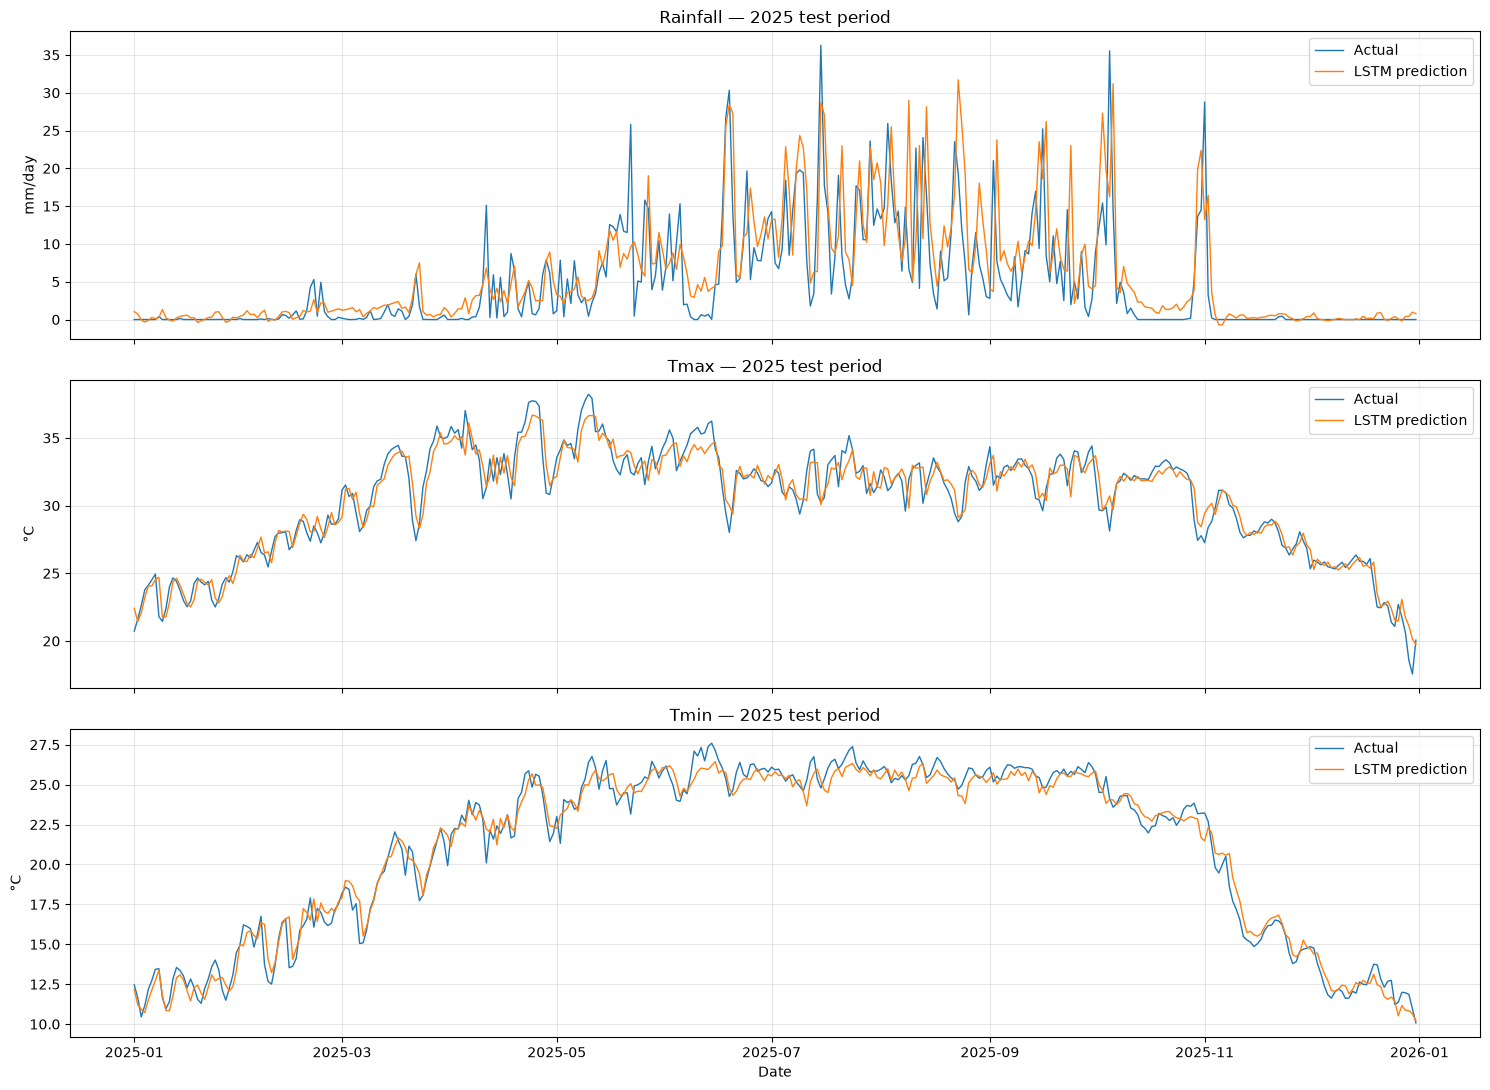

In [38]:

import matplotlib.pyplot as plt

test_dates = pd.to_datetime(test_data["target_dates"])

# Average across the 14 selected cells for each test day
actual_daily_mean = actual_valid.mean(axis=1)
pred_daily_mean = pred_valid.mean(axis=1)

fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)

for i, (variable, unit) in enumerate(zip(variable_names, units)):
    axes[i].plot(
        test_dates, actual_daily_mean[:, i],
        label="Actual", linewidth=1
    )
    axes[i].plot(
        test_dates, pred_daily_mean[:, i],
        label="LSTM prediction", linewidth=1
    )
    axes[i].set_title(f"{variable} — 2025 test period")
    axes[i].set_ylabel(unit)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


In [39]:

results_dir = "../results"
os.makedirs(results_dir, exist_ok=True)

metrics_path = os.path.join(
    results_dir, "lstm_1day_test_metrics.csv"
)

metrics_df.to_csv(metrics_path, index=False)

predictions_path = os.path.join(
    results_dir, "lstm_1day_test_predictions.npz"
)

np.savez_compressed(
    predictions_path,
    target_dates=np.asarray(test_dates, dtype="datetime64[ns]"),
    y_actual=y_actual.astype(np.float32),
    y_pred=y_pred.astype(np.float32),
    mask=mask.astype(bool),
    variables=np.asarray(variable_names, dtype=str)
)

print("Metrics saved:", metrics_path)
print("Predictions saved:", predictions_path)


Metrics saved: ../results\lstm_1day_test_metrics.csv
Predictions saved: ../results\lstm_1day_test_predictions.npz


In [40]:

# Persistence baseline: today's final input day predicts tomorrow.
# Reshape the final LSTM input from 105 climate features to (7, 5, 3).
last_day_norm = X_test[:, -1, :].reshape(-1, 7, 5, 3)

# The input contains the previous 7 days; the final day is the
# most recent observed day. Convert to original units.
persistence_pred = (
    last_day_norm * stds.reshape(1, 1, 1, 3)
    + means.reshape(1, 1, 1, 3)
)

# Actual targets in original units, with the forecast-horizon axis removed.
actual = y_actual[:, 0]

persistence_results = []

for i, variable in enumerate(variable_names):
    actual_values = actual[:, mask, i].ravel()
    predicted_values = persistence_pred[:, mask, i].ravel()

    persistence_results.append({
        "Variable": variable,
        "MAE": mean_absolute_error(actual_values, predicted_values),
        "RMSE": np.sqrt(
            mean_squared_error(actual_values, predicted_values)
        )
    })

print(pd.DataFrame(persistence_results).round(4).to_string(index=False))


Variable    MAE    RMSE
Rainfall 5.5132 13.8623
    Tmax 1.0052  1.3382
    Tmin 0.7061  0.9642


In [41]:

lstm_metrics = {
    "Rainfall": {"MAE": 5.2732, "RMSE": 10.8875},
    "Tmax": {"MAE": 1.0205, "RMSE": 1.3416},
    "Tmin": {"MAE": 0.7500, "RMSE": 0.9752}
}

persistence_metrics = {
    "Rainfall": {"MAE": 5.5132, "RMSE": 13.8623},
    "Tmax": {"MAE": 1.0052, "RMSE": 1.3382},
    "Tmin": {"MAE": 0.7061, "RMSE": 0.9642}
}

for variable in lstm_metrics:
    print(f"\n{variable}")
    for metric in ["MAE", "RMSE"]:
        lstm_value = lstm_metrics[variable][metric]
        persistence_value = persistence_metrics[variable][metric]

        reduction = (
            (persistence_value - lstm_value)
            / persistence_value
        ) * 100

        print(f"{metric} error reduction: {reduction:.2f}%")



Rainfall
MAE error reduction: 4.35%
RMSE error reduction: 21.46%

Tmax
MAE error reduction: -1.52%
RMSE error reduction: -0.25%

Tmin
MAE error reduction: -6.22%
RMSE error reduction: -1.14%


In [42]:

def add_mask_channel(X, mask):
    # X shape: (samples, time, latitude, longitude, 3)
    mask_channel = np.broadcast_to(
        mask.astype(np.float32)[None, None, :, :, None],
        (X.shape[0], X.shape[1], X.shape[2], X.shape[3], 1)
    )

    return np.concatenate([X, mask_channel], axis=-1).astype(
        np.float32
    )

X_train_conv = add_mask_channel(train_data["X_conv"], mask)
X_val_conv = add_mask_channel(val_data["X_conv"], mask)
X_test_conv = add_mask_channel(test_data["X_conv"], mask)

print("Training:", X_train_conv.shape)
print("Validation:", X_val_conv.shape)
print("Testing:", X_test_conv.shape)


Training: (2915, 7, 7, 5, 4)
Validation: (731, 7, 7, 5, 4)
Testing: (365, 7, 7, 5, 4)


In [43]:

import tensorflow as tf
from tensorflow.keras import layers, Model

tf.keras.utils.set_random_seed(42)

# Input: (time, latitude, longitude, channels)
conv_inputs = layers.Input(
    shape=(7, 7, 5, 4),
    name="climate_grid_history"
)

x = layers.ConvLSTM2D(
    filters=32,
    kernel_size=(3, 3),
    padding="same",
    return_sequences=False,
    activation="tanh",
    name="convlstm"
)(conv_inputs)

# Generate 3 climate variables at every grid location
x = layers.Conv2D(
    filters=3,
    kernel_size=(1, 1),
    padding="same",
    activation="linear",
    name="climate_forecast"
)(x)

# Add the one-day forecast dimension
outputs = layers.Reshape((1, 7, 5, 3))(x)

convlstm_model = Model(
    inputs=conv_inputs,
    outputs=outputs,
    name="VARUNA_ConvLSTM"
)

convlstm_model.summary()


Model: "VARUNA_ConvLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ climate_grid_history            │ (None, 7, 7, 5, 4)     │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convlstm (ConvLSTM2D)           │ (None, 7, 5, 32)       │        41,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ climate_forecast (Conv2D)       │ (None, 7, 5, 3)        │            99 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 1, 7, 5, 3)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,699 (162.89 KB)

 Trainable params: 41,699 (162.89 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:

mask_tf = tf.constant(
    mask.astype(np.float32)[None, None, :, :, None]
)

def masked_mse(y_true, y_pred):
    squared_error = tf.square(y_true - y_pred) * mask_tf

    denominator = (
        tf.reduce_sum(mask_tf)
        * tf.cast(
            tf.shape(y_true)[0] * tf.shape(y_true)[1] * 3,
            tf.float32
        )
    )

    return tf.reduce_sum(squared_error) / denominator

convlstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=masked_mse
)

print("ConvLSTM compiled successfully.")


ConvLSTM compiled successfully.


In [45]:

early_stopping_conv = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history_conv = convlstm_model.fit(
    X_train_conv,
    y_train,
    validation_data=(X_val_conv, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping_conv],
    shuffle=True,
    verbose=1
)


Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.3779 - val_loss: 0.2918
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2970 - val_loss: 0.2649
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2833 - val_loss: 0.2538
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2762 - val_loss: 0.2489
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2718 - val_loss: 0.2459
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2685 - val_loss: 0.2440
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.2659 - val_loss: 0.2426
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2637 - val_loss: 0.2415
Epoch 9/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.2618 - val_loss: 0.2406
Epoch 10/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.2600 - val_loss: 0.2398
Epoch 11/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2583 - val_loss: 0.2393
Epoch 12/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2

In [46]:

import os
import numpy as np

model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)

convlstm_path = os.path.join(
    model_dir, "varuna_convlstm_1day.keras"
)

convlstm_history_path = os.path.join(
    model_dir, "varuna_convlstm_1day_history.npz"
)

convlstm_model.save(convlstm_path)

np.savez_compressed(
    convlstm_history_path,
    loss=np.asarray(history_conv.history["loss"]),
    val_loss=np.asarray(history_conv.history["val_loss"])
)

print("Model saved:", convlstm_path)
print("History saved:", convlstm_history_path)


Model saved: ../models\varuna_convlstm_1day.keras
History saved: ../models\varuna_convlstm_1day_history.npz


In [47]:

best_epoch_conv = int(
    np.argmin(history_conv.history["val_loss"]) + 1
)
best_val_loss_conv = float(
    np.min(history_conv.history["val_loss"])
)

print("Epochs completed:", len(history_conv.history["loss"]))
print("Best epoch:", best_epoch_conv)
print("Best validation loss:", round(best_val_loss_conv, 4))


Epochs completed: 24
Best epoch: 16
Best validation loss: 0.2379


In [48]:

y_pred_conv_norm = convlstm_model.predict(
    X_test_conv,
    batch_size=32,
    verbose=1
)

# Convert normalized predictions and targets to original units
scale = stds.reshape(1, 1, 1, 1, 3)
offset = means.reshape(1, 1, 1, 1, 3)

y_pred_conv = y_pred_conv_norm * scale + offset
y_actual_conv = y_test * scale + offset

# Evaluate only the 14 selected cells
pred_valid_conv = y_pred_conv[:, 0][:, mask, :]
actual_valid_conv = y_actual_conv[:, 0][:, mask, :]

conv_results = []

for i, variable in enumerate(variable_names):
    actual_values = actual_valid_conv[:, :, i].ravel()
    predicted_values = pred_valid_conv[:, :, i].ravel()

    conv_results.append({
        "Variable": variable,
        "MAE": mean_absolute_error(
            actual_values, predicted_values
        ),
        "RMSE": np.sqrt(
            mean_squared_error(actual_values, predicted_values)
        )
    })

conv_metrics_df = pd.DataFrame(conv_results)
print(conv_metrics_df.round(4).to_string(index=False))


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Variable    MAE    RMSE
Rainfall 5.5135 10.8342
    Tmax 0.9848  1.2839
    Tmin 0.6638  0.8751


In [49]:

import os
import numpy as np
import tensorflow as tf

from tensorflow.keras import Model, layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("TensorFlow version:", tf.__version__)
print("Training input:", X_train_conv.shape)
print("Validation input:", X_val_conv.shape)
print("Training targets:", y_train.shape)
print("Validation targets:", y_val.shape)


TensorFlow version: 2.21.0
Training input: (2915, 7, 7, 5, 4)
Validation input: (731, 7, 7, 5, 4)
Training targets: (2915, 1, 7, 5, 3)
Validation targets: (731, 1, 7, 5, 3)


In [50]:

@tf.keras.utils.register_keras_serializable()
class TemporalAttentionPooling(layers.Layer):

    def call(self, inputs):
        features, weights = inputs

        # features: (batch, time, latitude, longitude, filters)
        # weights:  (batch, time, 1)

        weights = tf.reshape(
            weights,
            [
                tf.shape(weights)[0],
                tf.shape(weights)[1],
                1, 1, 1
            ]
        )

        # Apply each day's attention weight to its feature maps
        weighted_features = features * weights

        # Combine the weighted feature maps across time
        return tf.reduce_sum(weighted_features, axis=1)


In [51]:

inputs = layers.Input(
    shape=(7, 7, 5, 4),
    name="climate_input"
)

# Extract features while retaining all 7 time steps
features = layers.ConvLSTM2D(
    filters=32,
    kernel_size=(3, 3),
    padding="same",
    return_sequences=True,
    activation="tanh",
    name="convlstm_features"
)(inputs)

# Summarize each day's feature maps
pooled = layers.TimeDistributed(
    layers.GlobalAveragePooling2D(),
    name="daily_feature_summary"
)(features)

# Learn one attention score per day
scores = layers.Dense(
    1,
    name="temporal_attention_scores"
)(pooled)

# Convert scores into weights that sum to 1 over time
weights = layers.Softmax(
    axis=1,
    name="temporal_attention_weights"
)(scores)

# Combine all seven days using their learned weights
context = TemporalAttentionPooling(
    name="temporal_attention_pooling"
)([features, weights])

# Predict the 3 climate variables at each grid cell
x = layers.Conv2D(
    filters=3,
    kernel_size=(1, 1),
    padding="same",
    activation="linear",
    name="climate_prediction"
)(context)

outputs = layers.Reshape(
    (1, 7, 5, 3),
    name="next_day_forecast"
)(x)

attention_model = Model(
    inputs=inputs,
    outputs=outputs,
    name="VARUNA_ConvLSTM_TemporalAttention"
)

attention_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=masked_mse
)

attention_model.summary()


Model: "VARUNA_ConvLSTM_TemporalAttention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ climate_input       │ (None, 7, 7, 5,   │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convlstm_features   │ (None, 7, 7, 5,   │     41,600 │ climate_input[0]… │
│ (ConvLSTM2D)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ daily_feature_summ… │ (None, 7, 32)     │          0 │ convlstm_feature… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_attention… │ (None, 7, 1)      │         33 │ daily_feature_su… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_attention… │ (None, 7, 1)      │          0 │ temporal_attenti… │
│ (Softmax)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_attention… │ (None, 7, 5, 32)  │          0 │ convlstm_feature… │
│ (TemporalAttention… │                   │            │ temporal_attenti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ climate_prediction  │ (None, 7, 5, 3)   │         99 │ temporal_attenti… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ next_day_forecast   │ (None, 1, 7, 5,   │          0 │ climate_predicti… │
│ (Reshape)           │ 3)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 41,732 (163.02 KB)

 Trainable params: 41,732 (163.02 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:

model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)

attention_model_path = os.path.join(
    model_dir,
    "varuna_convlstm_attention_1day.keras"
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        attention_model_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

history_attention = attention_model.fit(
    X_train_conv,
    y_train,
    validation_data=(X_val_conv, y_val),
    epochs=50,
    batch_size=32,
    shuffle=True,
    callbacks=callbacks,
    verbose=1
)

print("Saved model:", attention_model_path)
print("Epochs completed:", len(history_attention.history["loss"]))
print(
    "Best validation loss:",
    min(history_attention.history["val_loss"])
)


Epoch 1/50
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.4420
Epoch 1: val_loss improved from None to 0.36290, saving model to ../models\varuna_convlstm_attention_1day.keras

Epoch 1: finished saving model to ../models\varuna_convlstm_attention_1day.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.4417 - val_loss: 0.3629
Epoch 2/50
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3381
Epoch 2: val_loss improved from 0.36290 to 0.29287, saving model to ../models\varuna_convlstm_attention_1day.keras

Epoch 2: finished saving model to ../models\varuna_convlstm_attention_1day.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.3371 - val_loss: 0.2929
Epoch 3/50
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2975
Epoch 3: val_loss improved from 0.29287 to 0.26427, saving model to ../models\varuna_convlstm_attention_1day.keras

Epoch 3: finished saving model to ../models\varuna_convlstm_attention_1day.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.2973 - val_loss:

In [53]:

attention_extractor = Model(
    inputs=attention_model.input,
    outputs=attention_model.get_layer(
        "temporal_attention_weights"
    ).output
)

attention_weights = attention_extractor.predict(
    X_test_conv,
    batch_size=32,
    verbose=1
)

print("Attention weights shape:", attention_weights.shape)

mean_weights = attention_weights.mean(axis=0).squeeze()

for day, weight in enumerate(mean_weights, start=1):
    print(f"Day {day} in the input window: {weight:.4f}")

print("Sum of mean attention weights:", mean_weights.sum())


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Attention weights shape: (365, 7, 1)
Day 1 in the input window: 0.0031
Day 2 in the input window: 0.0033
Day 3 in the input window: 0.0038
Day 4 in the input window: 0.0055
Day 5 in the input window: 0.0132
Day 6 in the input window: 0.0802
Day 7 in the input window: 0.8909
Sum of mean attention weights: 1.0


In [54]:

# Generate one-day-ahead predictions
pred_attention_norm = attention_model.predict(
    X_test_conv,
    batch_size=32,
    verbose=1
)

# Training-only normalization statistics, in variable order:
# rainfall, tmax, tmin
means = np.array(
    [4.645871, 30.690012, 20.315042],
    dtype=np.float32
)

stds = np.array(
    [13.518388, 4.541152, 5.800548],
    dtype=np.float32
)

# Undo normalization
pred_attention = (
    pred_attention_norm * stds[None, None, None, None, :]
    + means[None, None, None, None, :]
)

true_attention = (
    y_test * stds[None, None, None, None, :]
    + means[None, None, None, None, :]
)

# Compare only the 14 valid grid cells
mask = np.asarray(west_bengal_mask).astype(bool)
mask_2d = mask.reshape(7, 5)

variable_names = ["Rainfall", "Tmax", "Tmin"]
units = ["mm/day", "°C", "°C"]

for j, (name, unit) in enumerate(zip(variable_names, units)):
    actual = true_attention[:, 0, :, :, j][:, mask_2d]
    predicted = pred_attention[:, 0, :, :, j][:, mask_2d]

    mae = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))

    print(
        f"{name}: MAE = {mae:.4f} {unit}, "
        f"RMSE = {rmse:.4f} {unit}"
    )


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


NameError: name 'west_bengal_mask' is not defined

In [55]:
DATA_PATH = "../data/west_bengal_climate_final.nc"

ds = xr.open_dataset(DATA_PATH)
print(ds.data_vars)

Data variables:
    rainfall            (time, latitude, longitude) float64 1MB ...
    tmax                (time, latitude, longitude) float32 563kB ...
    tmin                (time, latitude, longitude) float32 563kB ...
    overlap_percentage  (latitude, longitude) float64 280B ...
    west_bengal_mask    (latitude, longitude) bool 35B ...


In [57]:

west_bengal_mask = ds["west_bengal_mask"].values.astype(bool)

print("Mask shape:", west_bengal_mask.shape)
print("Selected cells:", west_bengal_mask.sum())


Mask shape: (7, 5)
Selected cells: 14


In [58]:

for name in ds.data_vars:
    print(name, ds[name].dims, ds[name].shape)

print("Coordinates:", list(ds.coords))


rainfall ('time', 'latitude', 'longitude') (4018, 7, 5)
tmax ('time', 'latitude', 'longitude') (4018, 7, 5)
tmin ('time', 'latitude', 'longitude') (4018, 7, 5)
overlap_percentage ('latitude', 'longitude') (7, 5)
west_bengal_mask ('latitude', 'longitude') (7, 5)
Coordinates: ['time', 'latitude', 'longitude']


In [59]:
mask = np.asarray(west_bengal_mask).astype(bool)
mask_2d = mask.reshape(7, 5)

In [60]:

# Generate one-day-ahead predictions
pred_attention_norm = attention_model.predict(
    X_test_conv,
    batch_size=32,
    verbose=1
)

# Training-only normalization statistics, in variable order:
# rainfall, tmax, tmin
means = np.array(
    [4.645871, 30.690012, 20.315042],
    dtype=np.float32
)

stds = np.array(
    [13.518388, 4.541152, 5.800548],
    dtype=np.float32
)

# Undo normalization
pred_attention = (
    pred_attention_norm * stds[None, None, None, None, :]
    + means[None, None, None, None, :]
)

true_attention = (
    y_test * stds[None, None, None, None, :]
    + means[None, None, None, None, :]
)

# Compare only the 14 valid grid cells
mask = np.asarray(west_bengal_mask).astype(bool)
mask_2d = mask.reshape(7, 5)

variable_names = ["Rainfall", "Tmax", "Tmin"]
units = ["mm/day", "°C", "°C"]

for j, (name, unit) in enumerate(zip(variable_names, units)):
    actual = true_attention[:, 0, :, :, j][:, mask_2d]
    predicted = pred_attention[:, 0, :, :, j][:, mask_2d]

    mae = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))

    print(
        f"{name}: MAE = {mae:.4f} {unit}, "
        f"RMSE = {rmse:.4f} {unit}"
    )


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Rainfall: MAE = 5.6015 mm/day, RMSE = 10.7709 mm/day
Tmax: MAE = 0.9844 °C, RMSE = 1.2753 °C
Tmin: MAE = 0.6663 °C, RMSE = 0.8799 °C


In [62]:

import os
import pandas as pd

results = [
    ["Persistence", "Rainfall", 5.5132, 13.8623],
    ["LSTM", "Rainfall", 5.2732, 10.8875],
    ["ConvLSTM", "Rainfall", 5.5135, 10.8342],
    ["ConvLSTM + Attention", "Rainfall", 5.6015, 10.7709],

    ["Persistence", "Tmax", 1.0052, 1.3382],
    ["LSTM", "Tmax", 1.0205, 1.3416],
    ["ConvLSTM", "Tmax", 0.9848, 1.2839],
    ["ConvLSTM + Attention", "Tmax", 0.9844, 1.2753],

    ["Persistence", "Tmin", 0.7061, 0.9642],
    ["LSTM", "Tmin", 0.7500, 0.9752],
    ["ConvLSTM", "Tmin", 0.6638, 0.8751],
    ["ConvLSTM + Attention", "Tmin", 0.6663, 0.8799],
]

results_df = pd.DataFrame(
    results,
    columns=["Model", "Variable", "MAE", "RMSE"]
)

print(results_df.to_string(index=False))

results_dir = "../results"
os.makedirs(results_dir, exist_ok=True)

results_path = os.path.join(
    results_dir, "one_day_model_comparison.csv"
)
results_df.to_csv(results_path, index=False)

print("\nSaved comparison table to:", results_path)


               Model Variable    MAE    RMSE
         Persistence Rainfall 5.5132 13.8623
                LSTM Rainfall 5.2732 10.8875
            ConvLSTM Rainfall 5.5135 10.8342
ConvLSTM + Attention Rainfall 5.6015 10.7709
         Persistence     Tmax 1.0052  1.3382
                LSTM     Tmax 1.0205  1.3416
            ConvLSTM     Tmax 0.9848  1.2839
ConvLSTM + Attention     Tmax 0.9844  1.2753
         Persistence     Tmin 0.7061  0.9642
                LSTM     Tmin 0.7500  0.9752
            ConvLSTM     Tmin 0.6638  0.8751
ConvLSTM + Attention     Tmin 0.6663  0.8799

Saved comparison table to: ../results\one_day_model_comparison.csv


In [63]:

import os
import glob

model_dir = "../models"

print("Saved model files:")
for path in sorted(glob.glob(os.path.join(model_dir, "*.keras"))):
    print(os.path.basename(path))

print("\nTest data available:")
for name in ["X_test_lstm", "X_test_conv", "y_test"]:
    if name in globals():
        print(name, globals()[name].shape)
    else:
        print(name, "not currently defined")


Saved model files:
varuna_convlstm_1day.keras
varuna_convlstm_attention_1day.keras
varuna_lstm_1day.keras

Test data available:
X_test_lstm (365, 7, 140)
X_test_conv (365, 7, 7, 5, 4)
y_test (365, 1, 7, 5, 3)


All three models loaded successfully.
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


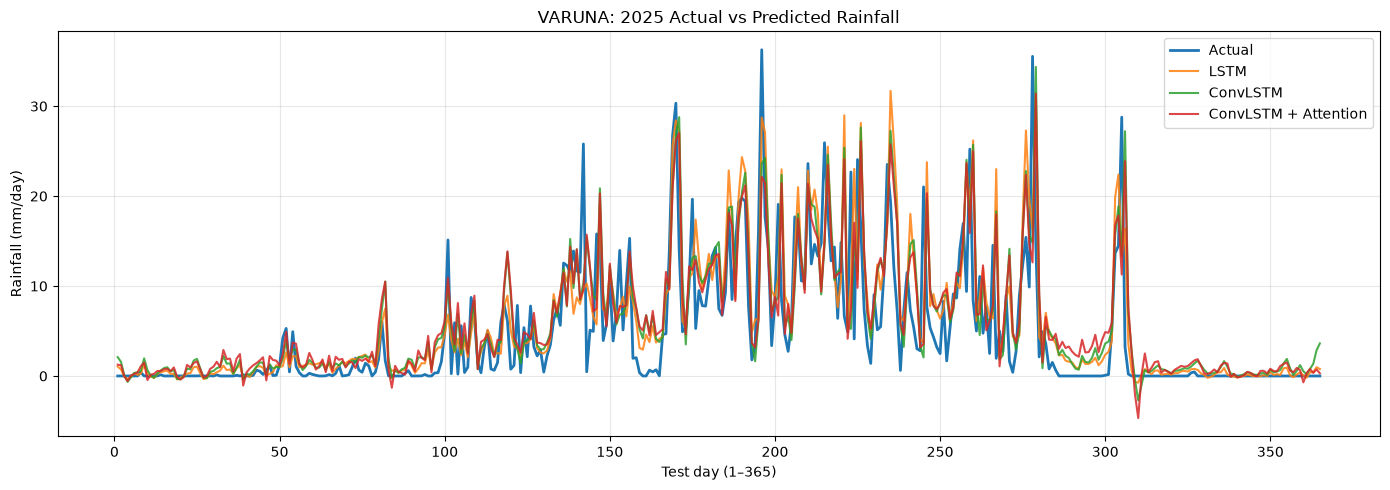

Saved: ../results\actual_vs_predicted_rainfall_2025.png


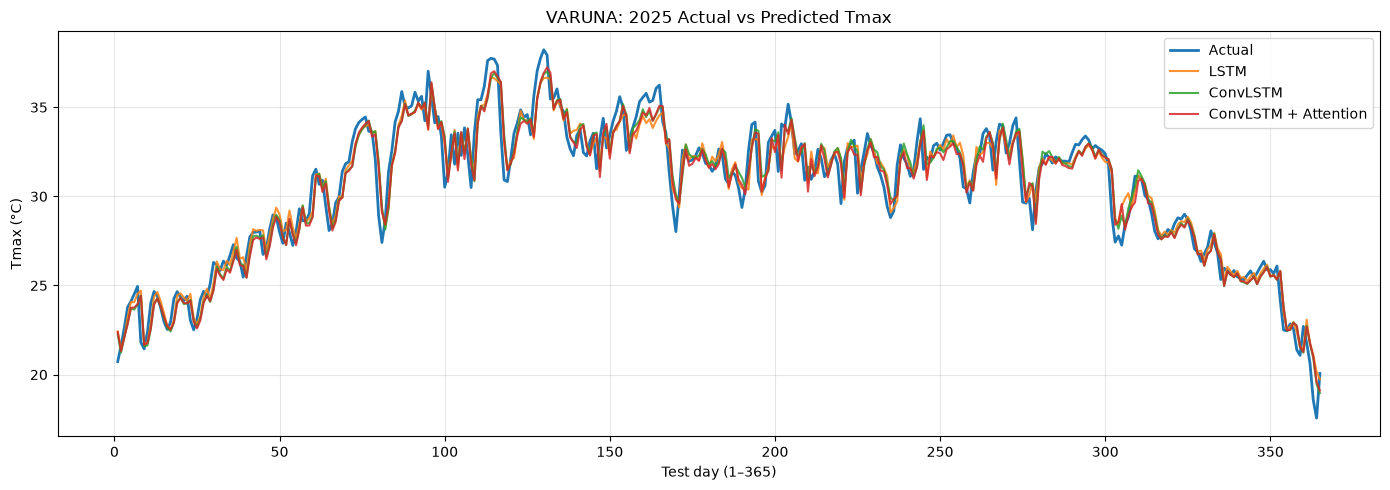

Saved: ../results\actual_vs_predicted_tmax_2025.png


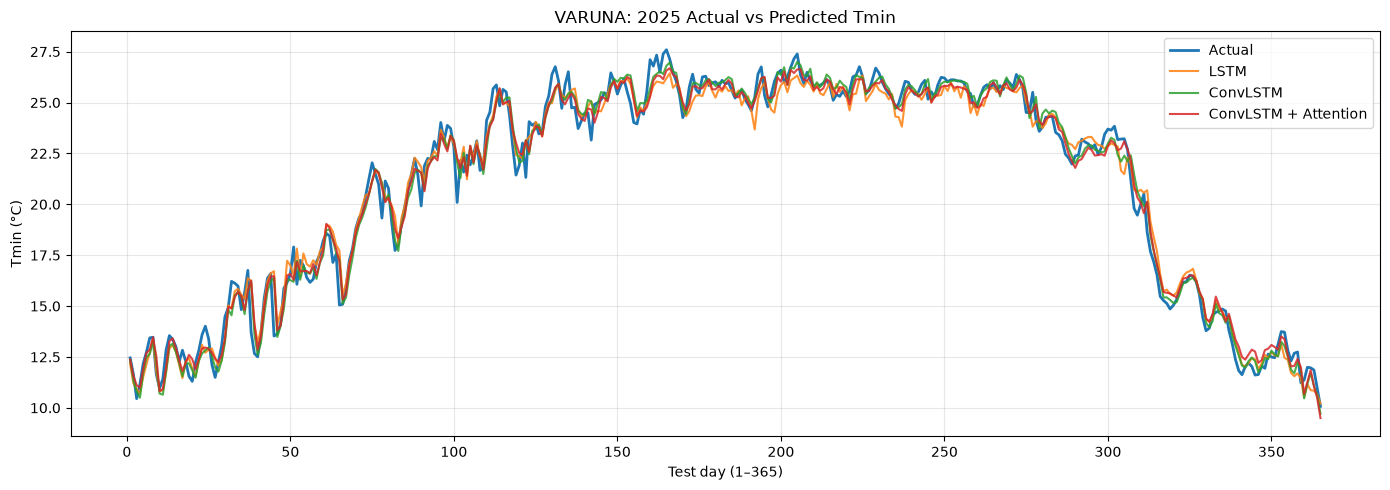

Saved: ../results\actual_vs_predicted_tmin_2025.png

All three plots generated.


In [65]:

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model

# --------------------------------------------------
# 1. Paths and output folder
# --------------------------------------------------
model_dir = "../models"
results_dir = "../results"
os.makedirs(results_dir, exist_ok=True)

# --------------------------------------------------
# 2. Load trained models
# --------------------------------------------------
lstm_model = load_model(
    os.path.join(model_dir, "varuna_lstm_1day.keras"),
    compile=False
)

convlstm_model = load_model(
    os.path.join(model_dir, "varuna_convlstm_1day.keras"),
    compile=False
)

attention_model = load_model(
    os.path.join(model_dir, "varuna_convlstm_attention_1day.keras"),
    custom_objects={
        "TemporalAttentionPooling": TemporalAttentionPooling
    },
    compile=False
)

print("All three models loaded successfully.")

# --------------------------------------------------
# 3. Generate normalized predictions
# --------------------------------------------------
pred_lstm_norm = lstm_model.predict(
    X_test_lstm, batch_size=32, verbose=1
)

pred_convlstm_norm = convlstm_model.predict(
    X_test_conv, batch_size=32, verbose=1
)

pred_attention_norm = attention_model.predict(
    X_test_conv, batch_size=32, verbose=1
)

# --------------------------------------------------
# 4. Convert predictions and actual targets to
#    original units: rainfall, Tmax, Tmin
# --------------------------------------------------
means = np.array(
    [4.645871, 30.690012, 20.315042],
    dtype=np.float32
)

stds = np.array(
    [13.518388, 4.541152, 5.800548],
    dtype=np.float32
)

def inverse_normalize(arr):
    return arr * stds[None, None, None, None, :] + \
           means[None, None, None, None, :]

true_values = inverse_normalize(y_test)
pred_lstm = inverse_normalize(pred_lstm_norm)
pred_convlstm = inverse_normalize(pred_convlstm_norm)
pred_attention = inverse_normalize(pred_attention_norm)

# --------------------------------------------------
# 5. Load spatial mask
# --------------------------------------------------
# west_bengal_mask should have been recovered earlier.
mask_2d = np.asarray(west_bengal_mask).astype(bool)

assert mask_2d.shape == (7, 5), (
    f"Expected mask shape (7, 5), got {mask_2d.shape}"
)
assert mask_2d.sum() == 14, (
    f"Expected 14 selected cells, got {mask_2d.sum()}"
)

# --------------------------------------------------
# 6. Daily regional average over selected grid cells
# --------------------------------------------------
# Shape after selecting the one-day forecast:
# (365, 7, 5, 3)
actual_grid = true_values[:, 0]
lstm_grid = pred_lstm[:, 0]
convlstm_grid = pred_convlstm[:, 0]
attention_grid = pred_attention[:, 0]

# Result: (365, 3)
actual_daily = np.stack([
    actual_grid[:, :, :, j][:, mask_2d].mean(axis=1)
    for j in range(3)
], axis=1)

lstm_daily = np.stack([
    lstm_grid[:, :, :, j][:, mask_2d].mean(axis=1)
    for j in range(3)
], axis=1)

convlstm_daily = np.stack([
    convlstm_grid[:, :, :, j][:, mask_2d].mean(axis=1)
    for j in range(3)
], axis=1)

attention_daily = np.stack([
    attention_grid[:, :, :, j][:, mask_2d].mean(axis=1)
    for j in range(3)
], axis=1)

# --------------------------------------------------
# 7. Plot and save each variable
# --------------------------------------------------
variable_names = ["Rainfall", "Tmax", "Tmin"]
units = ["mm/day", "°C", "°C"]
days = np.arange(1, len(y_test) + 1)

for j, variable in enumerate(variable_names):
    plt.figure(figsize=(14, 5))

    plt.plot(
        days, actual_daily[:, j],
        label="Actual", linewidth=2
    )
    plt.plot(
        days, lstm_daily[:, j],
        label="LSTM", alpha=0.85
    )
    plt.plot(
        days, convlstm_daily[:, j],
        label="ConvLSTM", alpha=0.85
    )
    plt.plot(
        days, attention_daily[:, j],
        label="ConvLSTM + Attention", alpha=0.85
    )

    plt.title(
        f"VARUNA: 2025 Actual vs Predicted {variable}"
    )
    plt.xlabel("Test day (1–365)")
    plt.ylabel(f"{variable} ({units[j]})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    save_path = os.path.join(
        results_dir,
        f"actual_vs_predicted_{variable.lower()}_2025.png"
    )
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)

print("\nAll three plots generated.")


In [66]:

# Check actual rainfall values in the 2025 test targets.
# y_test is normalized, so first convert it to mm/day.

rainfall_actual_grid = true_values[:, 0, :, :, 0]
mask_2d = np.asarray(west_bengal_mask).astype(bool)

# Daily regional mean across the 14 selected cells
rainfall_daily_mean = rainfall_actual_grid[:, mask_2d].mean(axis=1)

print("Minimum daily regional rainfall:",
      rainfall_daily_mean.min(), "mm/day")

negative_days = np.where(rainfall_daily_mean < 0)[0]

print("Days with negative regional rainfall (0-based):",
      negative_days)

if len(negative_days) > 0:
    for day in negative_days:
        print(
            f"Test day {day + 1}: "
            f"{rainfall_daily_mean[day]:.4f} mm/day"
        )


Minimum daily regional rainfall: 4.7683716e-07 mm/day
Days with negative regional rainfall (0-based): []


In [67]:

# Check the actual rainfall values at all selected grid cells.
selected_rainfall = rainfall_actual_grid[:, mask_2d]

print("Selected rainfall array shape:", selected_rainfall.shape)
print("Minimum selected rainfall:", selected_rainfall.min(), "mm/day")
print("Maximum selected rainfall:", selected_rainfall.max(), "mm/day")
print("Number of negative rainfall values:", 
      np.sum(selected_rainfall < 0))

# Locate any negative values, if present
negative_locations = np.argwhere(selected_rainfall < 0)

if len(negative_locations) > 0:
    print("First negative locations (day index, selected-cell index):")
    print(negative_locations[:10])
else:
    print("No negative rainfall values in selected grid cells.")


Selected rainfall array shape: (365, 14)
Minimum selected rainfall: 4.7683716e-07 mm/day
Maximum selected rainfall: 178.3271 mm/day
Number of negative rainfall values: 0
No negative rainfall values in selected grid cells.


In [68]:

import os
import numpy as np

sequence_dir = "../data/sequences"

required_files = [
    "train_3day.npz",
    "validation_3day.npz",
    "test_3day.npz",
]

print("Checking 3-day sequence files:\n")

for filename in required_files:
    path = os.path.join(sequence_dir, filename)
    print(filename, "->", "Found" if os.path.exists(path) else "Not found")


Checking 3-day sequence files:

train_3day.npz -> Found
validation_3day.npz -> Found
test_3day.npz -> Found


In [69]:

def load_sequence_file(filename):
    path = os.path.join(sequence_dir, filename)

    with np.load(path, allow_pickle=False) as data:
        print(f"\n{filename}")
        print("Available keys:", data.files)

        X_lstm = data["X_lstm"].astype(np.float32)
        X_conv = data["X_conv"].astype(np.float32)
        y = data["y"].astype(np.float32)

        target_dates = (
            data["target_dates"]
            if "target_dates" in data.files
            else None
        )

    print("X_lstm:", X_lstm.shape)
    print("X_conv:", X_conv.shape)
    print("y:", y.shape)

    return X_lstm, X_conv, y, target_dates


X_train_lstm_3, X_train_conv_3, y_train_3, dates_train_3 = (
    load_sequence_file("train_3day.npz")
)

X_val_lstm_3, X_val_conv_3, y_val_3, dates_val_3 = (
    load_sequence_file("validation_3day.npz")
)

X_test_lstm_3, X_test_conv_3, y_test_3, dates_test_3 = (
    load_sequence_file("test_3day.npz")
)



train_3day.npz
Available keys: ['X_lstm', 'X_conv', 'y', 'target_dates', 'mask', 'variables']


ValueError: Object arrays cannot be loaded when allow_pickle=False

In [70]:

import os
import numpy as np

def load_sequence_file(filename):
    path = os.path.join(sequence_dir, filename)

    with np.load(path, allow_pickle=False) as data:
        print(f"\n{filename}")
        print("Available keys:", data.files)

        X_conv = data["X_conv"].astype(np.float32)
        y = data["y"].astype(np.float32)

    print("X_conv:", X_conv.shape)
    print("y:", y.shape)

    return X_conv, y


# Load 3-day sequences for ConvLSTM
X_train_conv_3, y_train_3 = load_sequence_file("train_3day.npz")

X_val_conv_3, y_val_3 = load_sequence_file("validation_3day.npz")

X_test_conv_3, y_test_3 = load_sequence_file("test_3day.npz")



train_3day.npz
Available keys: ['X_lstm', 'X_conv', 'y', 'target_dates', 'mask', 'variables']
X_conv: (2913, 7, 7, 5, 3)
y: (2913, 3, 7, 5, 3)

validation_3day.npz
Available keys: ['X_lstm', 'X_conv', 'y', 'target_dates', 'mask', 'variables']
X_conv: (729, 7, 7, 5, 3)
y: (729, 3, 7, 5, 3)

test_3day.npz
Available keys: ['X_lstm', 'X_conv', 'y', 'target_dates', 'mask', 'variables']
X_conv: (363, 7, 7, 5, 3)
y: (363, 3, 7, 5, 3)


In [71]:
import numpy as np

print("Mask shape:", west_bengal_mask.shape)
print("Mask data type:", west_bengal_mask.dtype)
print("Cells inside West Bengal:", west_bengal_mask.sum())
print("Mask values:", np.unique(west_bengal_mask))

Mask shape: (7, 5)
Mask data type: bool
Cells inside West Bengal: 14
Mask values: [False  True]


In [72]:
def add_mask_channel(X, mask):
    # If the mask channel is already present, do not add it again.
    if X.shape[-1] == 4:
        print("Mask channel already present.")
        return X.astype(np.float32)

    if X.shape[-1] != 3:
        raise ValueError(f"Expected 3 or 4 channels, got {X.shape[-1]}")

    mask_channel = np.broadcast_to(
        mask.astype(np.float32)[None, None, :, :, None],
        (X.shape[0], X.shape[1], X.shape[2], X.shape[3], 1)
    )

    X_with_mask = np.concatenate([X, mask_channel], axis=-1)

    return X_with_mask.astype(np.float32)


X_train_conv_3 = add_mask_channel(X_train_conv_3, west_bengal_mask)
X_val_conv_3   = add_mask_channel(X_val_conv_3, west_bengal_mask)
X_test_conv_3  = add_mask_channel(X_test_conv_3, west_bengal_mask)

print("Training input:", X_train_conv_3.shape)
print("Validation input:", X_val_conv_3.shape)
print("Testing input:", X_test_conv_3.shape)

Training input: (2913, 7, 7, 5, 4)
Validation input: (729, 7, 7, 5, 4)
Testing input: (363, 7, 7, 5, 4)


In [73]:
def add_mask_channel(X, mask):
    # If the mask channel is already present, do not add it again.
    if X.shape[-1] == 4:
        print("Mask channel already present.")
        return X.astype(np.float32)

    if X.shape[-1] != 3:
        raise ValueError(f"Expected 3 or 4 channels, got {X.shape[-1]}")

    mask_channel = np.broadcast_to(
        mask.astype(np.float32)[None, None, :, :, None],
        (X.shape[0], X.shape[1], X.shape[2], X.shape[3], 1)
    )

    X_with_mask = np.concatenate([X, mask_channel], axis=-1)

    return X_with_mask.astype(np.float32)


X_train_conv_3 = add_mask_channel(X_train_conv_3, west_bengal_mask)
X_val_conv_3   = add_mask_channel(X_val_conv_3, west_bengal_mask)
X_test_conv_3  = add_mask_channel(X_test_conv_3, west_bengal_mask)

print("Training input:", X_train_conv_3.shape)
print("Validation input:", X_val_conv_3.shape)
print("Testing input:", X_test_conv_3.shape)

Mask channel already present.
Mask channel already present.
Mask channel already present.
Training input: (2913, 7, 7, 5, 4)
Validation input: (729, 7, 7, 5, 4)
Testing input: (363, 7, 7, 5, 4)


In [74]:
# Inspect the fourth channel of one input sequence
mask_in_data = X_train_conv_3[0, 0, :, :, 3]

print("Fourth channel shape:", mask_in_data.shape)
print("Unique values:", np.unique(mask_in_data))
print("Number of selected cells:", np.sum(mask_in_data == 1))
print("Matches West Bengal mask:",
      np.array_equal(mask_in_data, west_bengal_mask.astype(np.float32)))

Fourth channel shape: (7, 5)
Unique values: [0. 1.]
Number of selected cells: 14
Matches West Bengal mask: True


In [75]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU devices: []


In [76]:
mask_2d = west_bengal_mask.astype(np.float32)

mask_tf = tf.constant(
    mask_2d[None, None, :, :, None],
    dtype=tf.float32
)

def masked_mse(y_true, y_pred):
    squared_error = tf.square(y_true - y_pred) * mask_tf

    numerator = tf.reduce_sum(squared_error)

    denominator = (
        tf.reduce_sum(mask_tf)
        * tf.cast(tf.shape(y_true)[0], tf.float32)
        * tf.cast(tf.shape(y_true)[1], tf.float32)
        * tf.cast(tf.shape(y_true)[-1], tf.float32)
    )

    return numerator / denominator

In [77]:
def build_convlstm_forecaster(horizon=3):
    inputs = layers.Input(
        shape=(7, 7, 5, 4),
        name="weather_history"
    )

    x = layers.ConvLSTM2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        activation="tanh",
        return_sequences=False,
        name="convlstm"
    )(inputs)

    x = layers.Conv2D(
        filters=horizon * 3,
        kernel_size=(1, 1),
        padding="same",
        activation="linear",
        name="forecast_projection"
    )(x)

    outputs = layers.Reshape(
        (horizon, 7, 5, 3),
        name="three_day_forecast"
    )(x)

    model = Model(inputs, outputs, name="VARUNA_ConvLSTM_3day")

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss=masked_mse
    )

    return model


model_3day = build_convlstm_forecaster(horizon=3)

model_3day.summary()

Model: "VARUNA_ConvLSTM_3day"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ weather_history (InputLayer)    │ (None, 7, 7, 5, 4)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convlstm (ConvLSTM2D)           │ (None, 7, 5, 32)       │        41,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ forecast_projection (Conv2D)    │ (None, 7, 5, 9)        │           297 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ three_day_forecast (Reshape)    │ (None, 3, 7, 5, 3)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,897 (163.66 KB)

 Trainable params: 41,897 (163.66 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
import os
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model_dir = os.path.join(sequence_dir, "models")
os.makedirs(model_dir, exist_ok=True)

checkpoint_path = os.path.join(
    model_dir, "varuna_convlstm_3day.keras"
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

print("Model will be saved to:", checkpoint_path)

Model will be saved to: ../data/sequences\models\varuna_convlstm_3day.keras


In [79]:
history_3day = model_3day.fit(
    X_train_conv_3,
    y_train_3,
    validation_data=(X_val_conv_3, y_val_3),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, model_checkpoint],
    shuffle=True,
    verbose=1
)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5118
Epoch 1: val_loss improved from None to 0.40328, saving model to ../data/sequences\models\varuna_convlstm_3day.keras

Epoch 1: finished saving model to ../data/sequences\models\varuna_convlstm_3day.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.5118 - val_loss: 0.4033
Epoch 2/50
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3772
Epoch 2: val_loss improved from 0.40328 to 0.36842, saving model to ../data/sequences\models\varuna_convlstm_3day.keras

Epoch 2: finished saving model to ../data/sequences\models\varuna_convlstm_3day.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3756 - val_loss: 0.3684
Epoch 3/50
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3594
Epoch 3: val_loss improved from 0.36842 to 0.35650, saving model to ../data/sequences\models\varuna_convlstm_3day.keras

Epoch 3: finished saving model to ../data/sequences\models\varuna_convlstm_3day.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/s

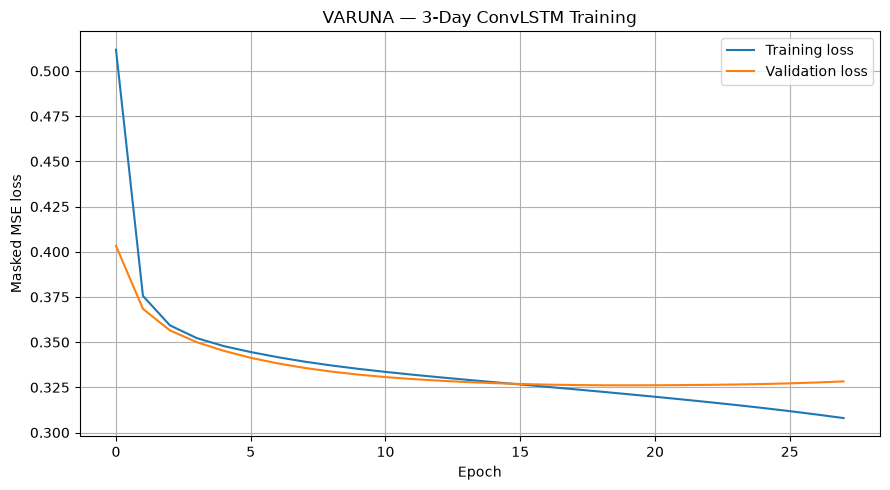

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    history_3day.history["loss"],
    label="Training loss"
)
plt.plot(
    history_3day.history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Masked MSE loss")
plt.title("VARUNA — 3-Day ConvLSTM Training")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [81]:
print("Test inputs:", X_test_conv_3.shape)
print("Test targets:", y_test_3.shape)

pred_3day_norm = model_3day.predict(
    X_test_conv_3,
    batch_size=32,
    verbose=1
)

print("Predictions:", pred_3day_norm.shape)

Test inputs: (363, 7, 7, 5, 4)
Test targets: (363, 3, 7, 5, 3)
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
Predictions: (363, 3, 7, 5, 3)


In [82]:
import numpy as np
import pandas as pd

# Original training-set normalization statistics
means = np.array(
    [4.645871, 30.690012, 20.315042],
    dtype=np.float32
)

stds = np.array(
    [13.518388, 4.541152, 5.800548],
    dtype=np.float32
)

# Convert normalized predictions and targets to original units
pred_3day = (
    pred_3day_norm * stds[None, None, None, None, :]
    + means[None, None, None, None, :]
)

actual_3day = (
    y_test_3 * stds[None, None, None, None, :]
    + means[None, None, None, None, :]
)

print("Predictions in original units:", pred_3day.shape)
print("Actual values in original units:", actual_3day.shape)

Predictions in original units: (363, 3, 7, 5, 3)
Actual values in original units: (363, 3, 7, 5, 3)


In [83]:
variables = ["Rainfall", "Tmax", "Tmin"]
units = ["mm/day", "°C", "°C"]

mask = west_bengal_mask.astype(bool)

results_3day = []

for day in range(3):
    for j, variable in enumerate(variables):

        # Select only the 14 masked grid cells
        actual_values = actual_3day[:, day, :, :, j][:, mask]
        predicted_values = pred_3day[:, day, :, :, j][:, mask]

        # Ignore invalid target values if any are present
        valid = np.isfinite(actual_values) & np.isfinite(predicted_values)

        actual_valid = actual_values[valid]
        predicted_valid = predicted_values[valid]

        mae = np.mean(np.abs(actual_valid - predicted_valid))
        rmse = np.sqrt(np.mean((actual_valid - predicted_valid) ** 2))

        results_3day.append({
            "Forecast day": day + 1,
            "Variable": variable,
            "MAE": mae,
            "RMSE": rmse,
            "Unit": units[j],
            "Valid observations": len(actual_valid)
        })

results_3day_df = pd.DataFrame(results_3day)

print(results_3day_df.round(4).to_string(index=False))

 Forecast day Variable    MAE    RMSE   Unit  Valid observations
            1 Rainfall 5.3550 10.7185 mm/day                5082
            1     Tmax 1.2592  1.6209     °C                5082
            1     Tmin 0.9921  1.2288     °C                5082
            2 Rainfall 5.3171 10.9418 mm/day                5082
            2     Tmax 1.4296  1.8383     °C                5082
            2     Tmin 1.0370  1.3206     °C                5082
            3 Rainfall 5.0579 10.9426 mm/day                5082
            3     Tmax 1.5789  2.0437     °C                5082
            3     Tmin 1.1810  1.5232     °C                5082


In [84]:
print("Non-finite normalized targets:",
      np.sum(~np.isfinite(y_test_3)))

print("Normalized target minimum:", np.nanmin(y_test_3))
print("Normalized target maximum:", np.nanmax(y_test_3))

Non-finite normalized targets: 0
Normalized target minimum: -3.705141
Normalized target maximum: 12.847776


In [85]:
# Convert targets back to original units
actual_3day_check = (
    y_test_3 * stds[None, None, None, None, :]
    + means[None, None, None, None, :]
)

for j, variable in enumerate(["Rainfall", "Tmax", "Tmin"]):
    values = actual_3day_check[..., j]

    print(f"\n{variable}")
    print("Minimum:", np.nanmin(values))
    print("Maximum:", np.nanmax(values))
    print("Non-finite values:", np.sum(~np.isfinite(values)))


Rainfall
Minimum: 4.7683716e-07
Maximum: 178.3271
Non-finite values: 0

Tmax
Minimum: 13.864403
Maximum: 41.53014
Non-finite values: 0

Tmin
Minimum: 7.3300257
Maximum: 29.521343
Non-finite values: 0


In [86]:
import numpy as np
import pandas as pd

# Last observed day from each 7-day input sequence.
# Input shape: (samples, 7, latitude, longitude, 4)
# The first 3 channels are normalized rainfall, Tmax, and Tmin.
last_day = X_test_conv_3[:, -1, :, :, :3]

# Repeat that observation for all 3 forecast days.
persistence_3day_norm = np.repeat(
    last_day[:, None, :, :, :],
    repeats=3,
    axis=1
)

print("Persistence predictions:", persistence_3day_norm.shape)

Persistence predictions: (363, 3, 7, 5, 3)


In [87]:
results_persistence_3day = []

for day in range(3):
    for j, variable in enumerate(["Rainfall", "Tmax", "Tmin"]):

        actual_values = actual_3day[:, day, :, :, j][:, mask]
        predicted_values = (
            persistence_3day_norm[:, day, :, :, j]
            * stds[j] + means[j]
        )[:, mask]

        valid = (
            np.isfinite(actual_values)
            & np.isfinite(predicted_values)
        )

        a = actual_values[valid]
        p = predicted_values[valid]

        results_persistence_3day.append({
            "Forecast day": day + 1,
            "Variable": variable,
            "MAE": np.mean(np.abs(a - p)),
            "RMSE": np.sqrt(np.mean((a - p) ** 2))
        })

persistence_df = pd.DataFrame(results_persistence_3day)

print(persistence_df.round(4).to_string(index=False))

 Forecast day Variable    MAE    RMSE
            1 Rainfall 5.5436 13.9004
            1     Tmax 1.0010  1.3325
            1     Tmin 0.7051  0.9638
            2 Rainfall 6.0063 14.8135
            2     Tmax 1.4671  1.9313
            2     Tmin 1.0130  1.3324
            3 Rainfall 6.4151 15.1934
            3     Tmax 1.7576  2.2756
            3     Tmin 1.1980  1.5824


In [88]:
import os

print("Model checkpoint exists:", os.path.exists(checkpoint_path))
print("Checkpoint path:", checkpoint_path)

# Save the current model with its restored best weights
final_model_path = os.path.join(
    model_dir, "varuna_convlstm_3day_final.keras"
)

model_3day.save(final_model_path)

print("Final model saved:", final_model_path)

Model checkpoint exists: True
Checkpoint path: ../data/sequences\models\varuna_convlstm_3day.keras
Final model saved: ../data/sequences\models\varuna_convlstm_3day_final.keras


In [89]:
results_3day_df.to_csv(
    os.path.join(model_dir, "convlstm_3day_metrics.csv"),
    index=False
)

persistence_df.to_csv(
    os.path.join(model_dir, "persistence_3day_metrics.csv"),
    index=False
)

print("Evaluation results saved.")

Evaluation results saved.


In [93]:
import xarray as xr
import numpy as np
import os

# If dataset_path is already defined, this will use it.
# Otherwise, replace the path below with your actual NetCDF path.
dataset_path = "../data/west_bengal_climate_final.nc"

ds = xr.open_dataset(dataset_path)

print("Dataset dimensions:")
print(ds.sizes)

print("\nAvailable variables:")
print(list(ds.data_vars))

print("\nTime coordinate:")
print(ds["time"].values[0], "to", ds["time"].values[-1])

print("\nClimate variable summaries:")
for var in ["rainfall", "tmax", "tmin"]:
    if var in ds:
        values = ds[var].values
        print(
            var,
            "| shape:", values.shape,
            "| NaNs:", np.isnan(values).sum(),
            "| min:", np.nanmin(values),
            "| max:", np.nanmax(values)
        )

Dataset dimensions:
Frozen({'time': 4018, 'latitude': 7, 'longitude': 5})

Available variables:
['rainfall', 'tmax', 'tmin', 'overlap_percentage', 'west_bengal_mask']

Time coordinate:
2015-01-01T00:00:00.000000000 to 2025-12-31T00:00:00.000000000

Climate variable summaries:
rainfall | shape: (4018, 7, 5) | NaNs: 84378 | min: 0.0 | max: 418.51422119140625
tmax | shape: (4018, 7, 5) | NaNs: 84378 | min: 12.307343 | max: 44.6321
tmin | shape: (4018, 7, 5) | NaNs: 84378 | min: 2.8297887 | max: 30.676022


In [94]:
test_file = os.path.join(sequence_dir, "test_3day.npz")

with np.load(test_file, allow_pickle=True) as data:
    target_dates = data["target_dates"]

print("Target dates shape:", target_dates.shape)
print("Target dates data type:", target_dates.dtype)
print("First few target dates:")
print(target_dates[:3])

Target dates shape: (363,)
Target dates data type: object
First few target dates:
[Timestamp('2025-01-01 00:00:00') Timestamp('2025-01-02 00:00:00')
 Timestamp('2025-01-03 00:00:00')]


In [95]:
# Convert the saved target dates to day-level timestamps
dates = np.asarray(target_dates).astype("datetime64[D]")

# Expected target date shape: (363, 3)
assert dates.shape == y_test_3.shape[:2], (
    f"Date shape {dates.shape} does not match target shape "
    f"{y_test_3.shape[:2]}"
)

# Confirm that every target date exists in the NetCDF
netcdf_dates = ds["time"].values.astype("datetime64[D]")
available_dates = set(netcdf_dates)

missing_dates = [
    str(d) for d in dates.ravel()
    if d not in available_dates
]

print("Target dates missing from NetCDF:", len(missing_dates))
if missing_dates:
    print("Examples:", missing_dates[:10])
    raise ValueError("Some target dates do not exist in the NetCDF.")

# Retrieve source values in exactly the same date order as the targets.
# Result shape: (samples, forecast days, latitude, longitude, variables)
source_arrays = []

for var in ["rainfall", "tmax", "tmin"]:
    source = ds[var].sel(time=dates.ravel())
    source_values = source.values.reshape(
        len(dates), dates.shape[1],
        ds.sizes["latitude"], ds.sizes["longitude"]
    )
    source_arrays.append(source_values)

source_targets = np.stack(source_arrays, axis=-1)

print("Original source target shape:", source_targets.shape)

AssertionError: Date shape (363,) does not match target shape (363, 3)

In [96]:
print("target_dates shape:", np.asarray(target_dates).shape)
print("target_dates dtype:", np.asarray(target_dates).dtype)
print("First 5 saved dates:")
print(np.asarray(target_dates)[:5])

print("\ny_test_3 shape:", y_test_3.shape)

target_dates shape: (363,)
target_dates dtype: object
First 5 saved dates:
[Timestamp('2025-01-01 00:00:00') Timestamp('2025-01-02 00:00:00')
 Timestamp('2025-01-03 00:00:00') Timestamp('2025-01-04 00:00:00')
 Timestamp('2025-01-05 00:00:00')]

y_test_3 shape: (363, 3, 7, 5, 3)


In [97]:
# Each saved date is assumed to be the first forecast day
first_dates = np.asarray(target_dates).astype("datetime64[D]")

# Create dates for all 3 forecast days
dates = first_dates[:, None] + np.arange(3)[None, :]

print("Corrected dates shape:", dates.shape)
print("First sample's forecast dates:", dates[0])
print("Last sample's forecast dates:", dates[-1])

assert dates.shape == y_test_3.shape[:2]

Corrected dates shape: (363, 3)
First sample's forecast dates: ['2025-01-01' '2025-01-02' '2025-01-03']
Last sample's forecast dates: ['2025-12-29' '2025-12-30' '2025-12-31']


In [98]:
# Check the first and last dates in the original dataset
print("Original NetCDF time range:")
print(ds["time"].values[0], "to", ds["time"].values[-1])

print("\nCorrected target dates:")
print("First sample:", dates[0])
print("Second sample:", dates[1])
print("Last sample:", dates[-1])

# Check whether the corrected dates exist in the NetCDF
netcdf_dates = ds["time"].values.astype("datetime64[D]")
flat_dates = dates.ravel()

missing_dates = np.setdiff1d(np.unique(flat_dates), netcdf_dates)

print("\nUnique forecast dates:", len(np.unique(flat_dates)))
print("Dates missing from NetCDF:", len(missing_dates))
if len(missing_dates) > 0:
    print(missing_dates[:10])

Original NetCDF time range:
2015-01-01T00:00:00.000000000 to 2025-12-31T00:00:00.000000000

Corrected target dates:
First sample: ['2025-01-01' '2025-01-02' '2025-01-03']
Second sample: ['2025-01-02' '2025-01-03' '2025-01-04']
Last sample: ['2025-12-29' '2025-12-30' '2025-12-31']

Unique forecast dates: 365
Dates missing from NetCDF: 0


In [99]:
source_arrays = []

for var in ["rainfall", "tmax", "tmin"]:
    source = ds[var].sel(time=dates.ravel())

    values = source.values.reshape(
        len(dates),
        dates.shape[1],
        ds.sizes["latitude"],
        ds.sizes["longitude"]
    )

    source_arrays.append(values)

source_targets = np.stack(source_arrays, axis=-1)

print("Original source targets shape:", source_targets.shape)
print("Expected target shape:", y_test_3.shape)
assert source_targets.shape == y_test_3.shape

Original source targets shape: (363, 3, 7, 5, 3)
Expected target shape: (363, 3, 7, 5, 3)


In [100]:
for var in ["rainfall", "tmax", "tmin"]:
    da = ds[var]
    values = da.values

    print(f"\n{'='*45}")
    print(f"Variable: {var}")
    print("Attributes:", da.attrs)
    print("Encoding:", da.encoding)
    print("Total values:", values.size)
    print("NaN values:", np.isnan(values).sum())
    print("Infinite values:", np.isinf(values).sum())

    if var == "rainfall":
        print("Values equal to -999:", np.sum(values == -999))
    else:
        print("Values equal to 99.9:", np.sum(np.isclose(values, 99.9)))


Variable: rainfall
Attributes: {'units': 'mm/day', 'source': 'IMD'}
Encoding: {'dtype': dtype('float64'), 'zlib': False, 'szip': False, 'zstd': False, 'bzip2': False, 'blosc': False, 'shuffle': False, 'complevel': 0, 'fletcher32': False, 'contiguous': True, 'chunksizes': None, 'source': 'd:\\VARUNA\\data\\west_bengal_climate_final.nc', 'original_shape': (4018, 7, 5), '_FillValue': np.float64(nan)}
Total values: 140630
NaN values: 84378
Infinite values: 0
Values equal to -999: 0

Variable: tmax
Attributes: {'units': 'degree Celsius', 'source': 'IMD'}
Encoding: {'dtype': dtype('float32'), 'zlib': False, 'szip': False, 'zstd': False, 'bzip2': False, 'blosc': False, 'shuffle': False, 'complevel': 0, 'fletcher32': False, 'contiguous': True, 'chunksizes': None, 'source': 'd:\\VARUNA\\data\\west_bengal_climate_final.nc', 'original_shape': (4018, 7, 5), '_FillValue': np.float32(nan)}
Total values: 140630
NaN values: 84378
Infinite values: 0
Values equal to 99.9: 0

Variable: tmin
Attributes: 

In [101]:
mask = west_bengal_mask.astype(bool)

# Select only the grid cells included in your mask
selected_source = source_targets[:, :, mask, :]

# Start by treating finite values as valid
valid_source = np.isfinite(selected_source)

# Exclude known missing-data sentinels
valid_source[..., 0] &= selected_source[..., 0] != -999
valid_source[..., 1] &= ~np.isclose(selected_source[..., 1], 99.9)
valid_source[..., 2] &= ~np.isclose(selected_source[..., 2], 99.9)

print("Selected source shape:", selected_source.shape)
print("Valid source observations by variable:")

for i, var in enumerate(["rainfall", "tmax", "tmin"]):
    print(
        f"{var}: {valid_source[..., i].sum()} valid, "
        f"{valid_source[..., i].size - valid_source[..., i].sum()} invalid"
    )

Selected source shape: (363, 3, 14, 3)
Valid source observations by variable:
rainfall: 15246 valid, 0 invalid
tmax: 15246 valid, 0 invalid
tmin: 15246 valid, 0 invalid


In [102]:
# Select the grid cells included in the West Bengal mask
mask = west_bengal_mask.astype(bool)

selected_source = source_targets[:, :, mask, :]

# Original observations are valid only when finite
valid_source = np.isfinite(selected_source)

print("Selected source shape:", selected_source.shape)
print("\nOriginal NetCDF valid/invalid counts:")

for i, var in enumerate(["rainfall", "tmax", "tmin"]):
    total = valid_source[..., i].size
    valid = valid_source[..., i].sum()
    print(
        f"{var}: {valid} valid, {total - valid} invalid "
        f"out of {total}"
    )

# Convert normalized saved targets back to original units
target_original_units = (
    y_test_3 * stds[None, None, None, None, :]
    + means[None, None, None, None, :]
)

selected_targets = target_original_units[:, :, mask, :]
valid_targets = np.isfinite(selected_targets)

print("\nSaved test-target valid/invalid counts:")

for i, var in enumerate(["rainfall", "tmax", "tmin"]):
    total = valid_targets[..., i].size
    valid = valid_targets[..., i].sum()
    print(
        f"{var}: {valid} valid, {total - valid} invalid "
        f"out of {total}"
    )

Selected source shape: (363, 3, 14, 3)

Original NetCDF valid/invalid counts:
rainfall: 15246 valid, 0 invalid out of 15246
tmax: 15246 valid, 0 invalid out of 15246
tmin: 15246 valid, 0 invalid out of 15246

Saved test-target valid/invalid counts:
rainfall: 15246 valid, 0 invalid out of 15246
tmax: 15246 valid, 0 invalid out of 15246
tmin: 15246 valid, 0 invalid out of 15246


In [103]:
print("Comparing saved targets with original NetCDF values:")

for i, var in enumerate(["rainfall", "tmax", "tmin"]):
    src = selected_source[..., i]
    tgt = selected_targets[..., i]

    # Only compare locations where the source is genuinely valid
    valid = np.isfinite(src) & np.isfinite(tgt)

    if valid.sum() == 0:
        print(f"{var}: No overlapping valid observations.")
        continue

    difference = np.abs(src[valid] - tgt[valid])

    print(
        f"{var}: compared={valid.sum()}, "
        f"MAE difference={difference.mean():.8f}, "
        f"maximum difference={difference.max():.8f}"
    )

Comparing saved targets with original NetCDF values:
rainfall: compared=15246, MAE difference=0.00000047, maximum difference=0.00000763
tmax: compared=15246, MAE difference=0.00017186, maximum difference=0.00019741
tmin: compared=15246, MAE difference=0.00003220, maximum difference=0.00005341


In [104]:
# Check the original NetCDF for the 2025 test period
ds_2025 = ds.sel(time=slice("2025-01-01", "2025-12-31"))

mask = west_bengal_mask.astype(bool)

print("2025 time steps:", ds_2025.sizes["time"])
print("Selected grid cells:", mask.sum())

for var in ["rainfall", "tmax", "tmin"]:
    values = ds_2025[var].values[:, mask]

    print(f"\n{var}")
    print("Shape:", values.shape)
    print("Total observations:", values.size)
    print("Missing observations:", np.isnan(values).sum())
    print("Valid observations:", np.isfinite(values).sum())

2025 time steps: 365
Selected grid cells: 14

rainfall
Shape: (365, 14)
Total observations: 5110
Missing observations: 0
Valid observations: 5110

tmax
Shape: (365, 14)
Total observations: 5110
Missing observations: 0
Valid observations: 5110

tmin
Shape: (365, 14)
Total observations: 5110
Missing observations: 0
Valid observations: 5110
